In [ ]:
#Import required libraries
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

<hr/>

### Open raster file

In [2]:
lakeRst = rasterio.open('../Rst/lakeBottomElevation.tif')
lakeRst.count

1

In [3]:
#raster resolution
lakeRst.res

(0.5, 0.5)

In [4]:
#all raster crs info
lakeRst.crs.wkt

'PROJCS["NAD83(2011) / Puerto Rico and Virgin Is.",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",17.8333333333333],PARAMETER["central_meridian",-66.4333333333333],PARAMETER["standard_parallel_1",18.4333333333333],PARAMETER["standard_parallel_2",18.0333333333333],PARAMETER["false_easting",200000],PARAMETER["false_northing",200000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","6566"]]'

<hr/>

### Get raster values as Numpy array

In [5]:
lakeBottom = lakeRst.read(1)

In [6]:
#raster sample
lakeBottom[:5,:5]

array([[-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, -3.4028235e+38,
        -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, -3.4028235e+38,
        -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, -3.4028235e+38,
        -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, -3.4028235e+38,
        -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, -3.4028235e+38,
        -3.4028235e+38]], dtype=float32)

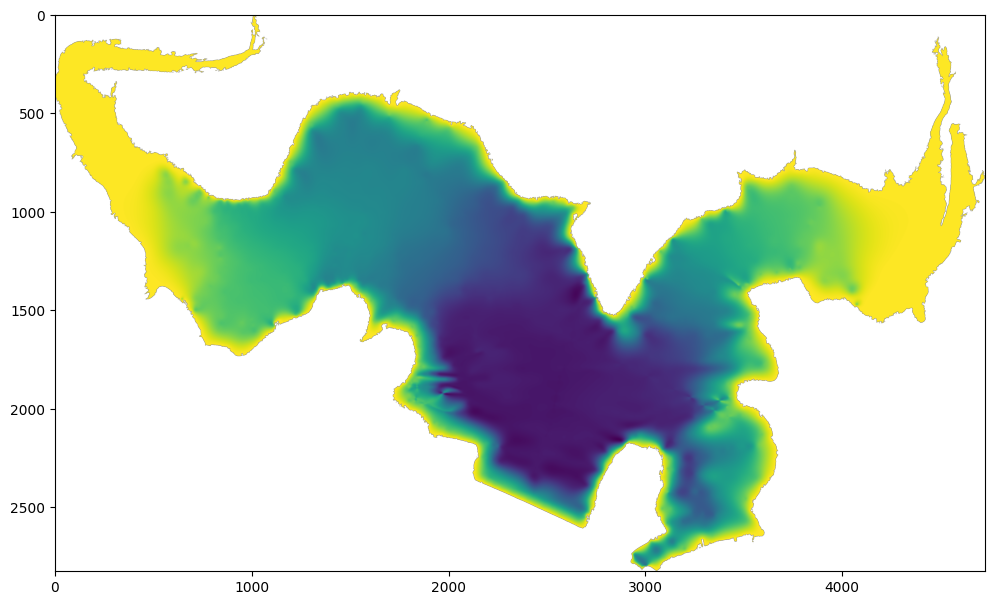

In [7]:
#replace value for np.nan
noDataValue = np.copy(lakeBottom[0,0])

lakeBottom[lakeBottom==noDataValue]= np.nan
plt.figure(figsize=(12,12))
plt.imshow(lakeBottom)
plt.show()

<hr/>

### Lake volume calculation

In [8]:
# get raster minimum and maximum 
minElev = np.nanmin(lakeBottom)
maxElev = np.nanmax(lakeBottom)
print('Min bottom elevation %.2f m., max bottom elevation %.2f m.'%(minElev,maxElev))

# steps for calculation
nSteps = 20

# lake bottom elevation intervals
elevSteps = np.round(np.linspace(minElev,maxElev,nSteps),2)
elevSteps

Min bottom elevation 44.10 m., max bottom elevation 67.55 m.


array([44.1 , 45.33, 46.56, 47.8 , 49.03, 50.27, 51.5 , 52.74, 53.97,
       55.21, 56.44, 57.67, 58.91, 60.14, 61.38, 62.61, 63.85, 65.08,
       66.32, 67.55], dtype=float32)

In [9]:
# definition of volume function
def calculateVol(elevStep,elevDem,lakeRst):
    tempDem = elevStep - elevDem[elevDem<elevStep]
    tempVol = tempDem.sum()*lakeRst.res[0]*lakeRst.res[1]
    return tempVol

In [10]:
# calculate volumes for each elevation
volArray = []
for elev in elevSteps:
    tempVol = calculateVol(elev,lakeBottom,lakeRst)
    volArray.append(tempVol)
    
print("Lake bottom elevations %s"%elevSteps)
volArrayMCM = [round(i/1000000,2) for i in volArray]
print("Lake volume in million of cubic meters %s"%volArrayMCM)

Lake bottom elevations [44.1  45.33 46.56 47.8  49.03 50.27 51.5  52.74 53.97 55.21 56.44 57.67
 58.91 60.14 61.38 62.61 63.85 65.08 66.32 67.55]
Lake volume in million of cubic meters [np.float32(0.0), np.float32(0.0), np.float32(0.13), np.float32(0.38), np.float32(0.68), np.float32(1.02), np.float32(1.4), np.float32(1.83), np.float32(2.31), np.float32(2.88), np.float32(3.56), np.float32(4.3), np.float32(5.1), np.float32(5.97), np.float32(6.91), np.float32(7.92), np.float32(8.99), np.float32(10.12), np.float32(11.3), np.float32(12.54)]


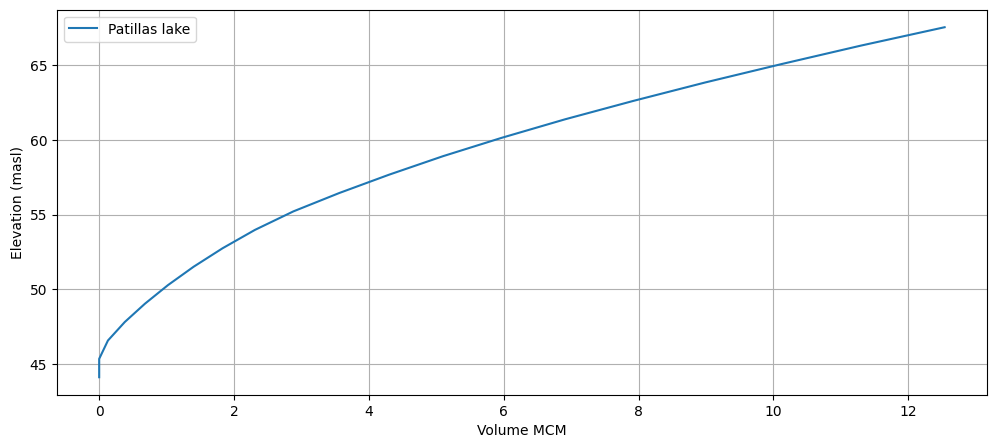

In [11]:
# plot values
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(volArrayMCM,elevSteps,label='Patillas lake')
ax.grid()
ax.legend()
ax.set_xlabel('Volume MCM')
ax.set_ylabel('Elevation (masl)')
plt.show()

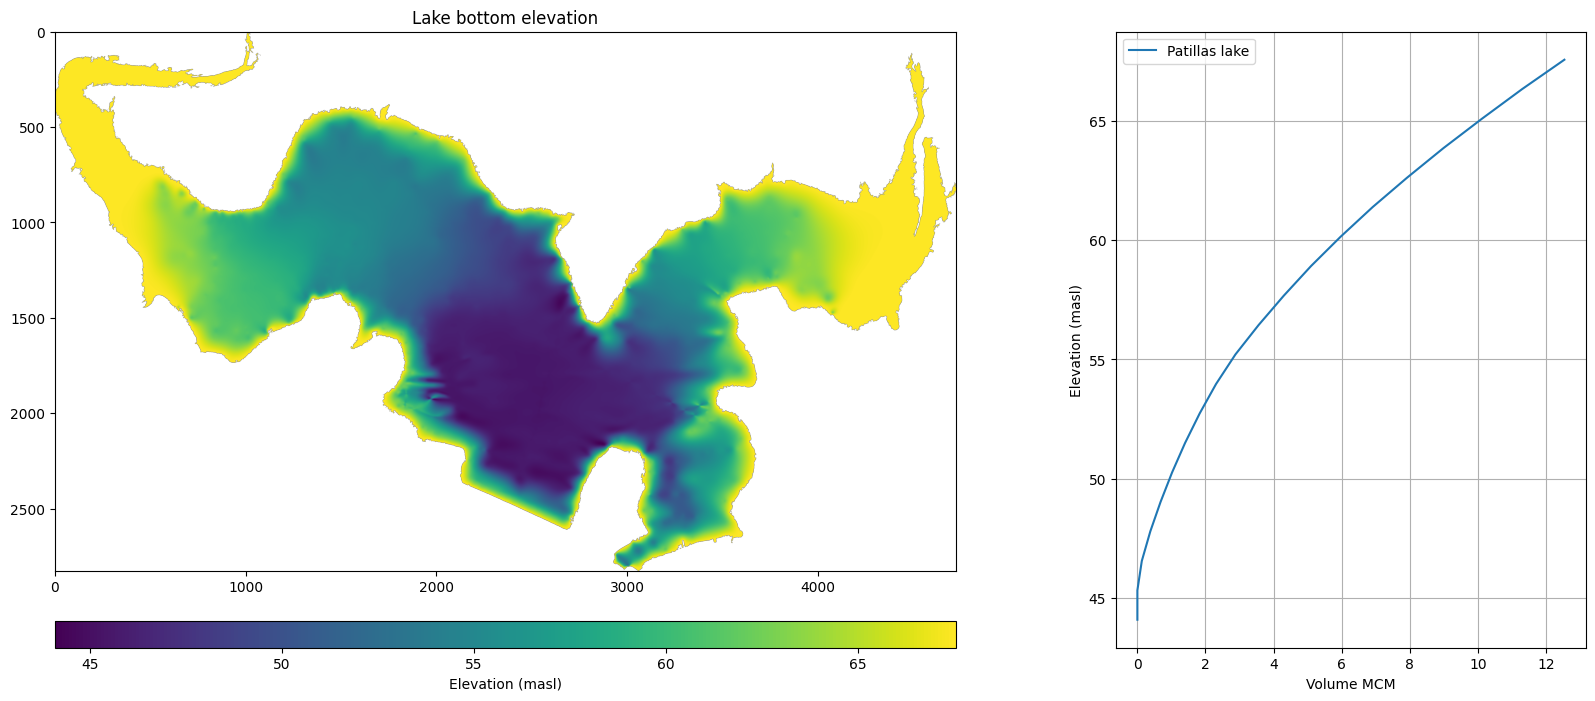

In [12]:
# plot values
fig, [ax1, ax2] = plt.subplots(1,2,figsize=(20,8),gridspec_kw={'width_ratios': [2, 1]})
ax1.set_title('Lake bottom elevation')
botElev = ax1.imshow(lakeBottom)

divider = make_axes_locatable(ax1)
cax = divider.append_axes('bottom', size='5%', pad=0.5)
fig.colorbar(botElev, cax=cax, orientation='horizontal', label='Elevation (masl)') 

ax2.plot(volArrayMCM,elevSteps,label='Patillas lake')
ax2.grid()
ax2.legend()
ax2.set_xlabel('Volume MCM')
ax2.set_ylabel('Elevation (masl)')
plt.show()

<hr/>

### Comparison with the USGS survey

From this pu

In [13]:
patVol = pd.read_csv('../Txt/patillasVolume.csv')
patVol.head()

,OBJECTID,Pool_Elevation_m,Storage_capacity_mcm
0,1,67.55,12.96
1,2,66.55,11.79
2,3,65.55,10.68
3,4,64.55,9.64
4,5,63.55,8.70


Text(0, 0.5, 'Elevation (masl)')

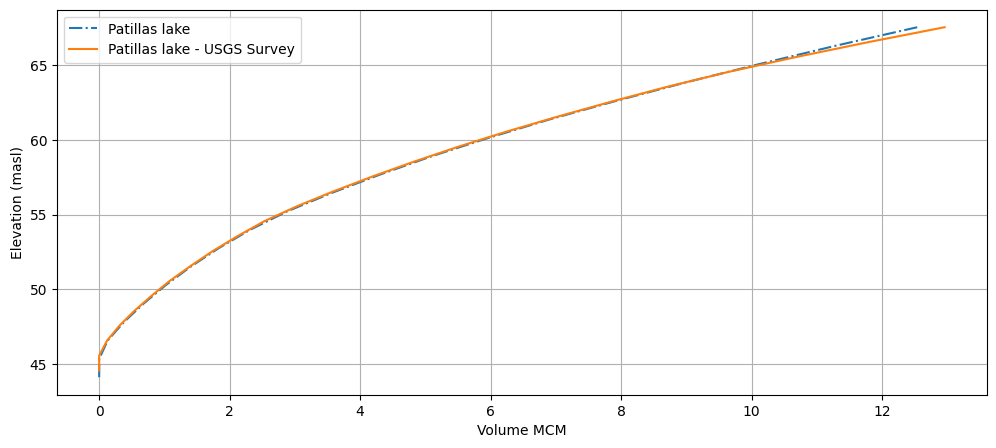

In [14]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(volArrayMCM,elevSteps,label='Patillas lake',ls= '-.')
ax.plot(patVol['Storage_capacity_mcm'],patVol['Pool_Elevation_m'],label='Patillas lake - USGS Survey')
ax.grid()
ax.legend()
ax.set_xlabel('Volume MCM')
ax.set_ylabel('Elevation (masl)')